# 🚀 Day 39 — CNNs, Image Classification & Transfer Learning

## Topics Covered
- Image Classification Basics
- CNN Architecture
- Convolution, ReLU, Pooling
- Building CNN from Scratch
- Transfer Learning using MobileNetV2
- Fine-Tuning CNN
- Real-World Applications

---

# 🎯 Learning Goals

By the end of this notebook, you will:
- Understand how CNNs process images
- Build a CNN from scratch
- Train image classifier on custom data
- Use pretrained models
- Perform transfer learning
- Fine-tune a CNN professionally



# 🧠 Why CNNs?

Traditional ANN struggles with images because:
- Too many parameters
- Spatial information gets lost
- Very inefficient for image processing

CNNs solve this by:
✅ Learning local patterns  
✅ Detecting edges and textures  
✅ Sharing weights using filters  
✅ Building hierarchical understanding  

---

# 🏗 CNN Pipeline

```text
Image
 ↓
Convolution
 ↓
ReLU
 ↓
Pooling
 ↓
Flatten
 ↓
Dense Layer
 ↓
Prediction
```



# 📦 Install & Import Libraries


In [1]:

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

import matplotlib.pyplot as plt
import numpy as np

print("TensorFlow Version:", tf.__version__)


TensorFlow Version: 2.21.0



# 📂 Dataset

We will use the CIFAR-10 dataset.

Classes:
- airplane
- automobile
- bird
- cat
- deer
- dog
- frog
- horse
- ship
- truck

This is one of the most famous beginner Computer Vision datasets.


In [2]:

# Load CIFAR-10 Dataset

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

print("Training Images:", x_train.shape)
print("Testing Images:", x_test.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 48s 0us/step
Training Images: (50000, 32, 32, 3)
Testing Images: (10000, 32, 32, 3)


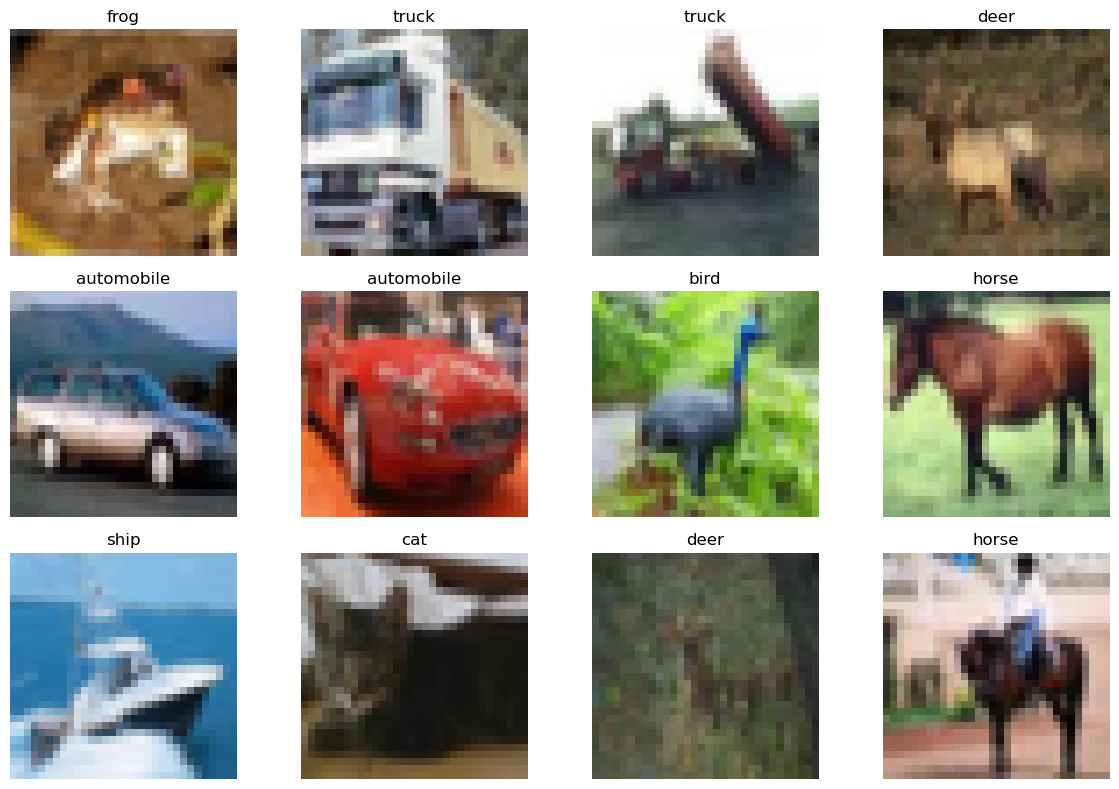

In [3]:

# 🔍 Visualize Sample Images

plt.figure(figsize=(12,8))

for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.show()


In [4]:

# ⚙ Normalize Images

x_train = x_train / 255.0
x_test = x_test / 255.0



# 🏗 Part 1 — Build CNN From Scratch

We will now create our own CNN.

Architecture:
- Conv2D
- ReLU
- MaxPooling
- Conv2D
- MaxPooling
- Flatten
- Dense
- Output Layer


In [5]:

# Build CNN Model

cnn_model = models.Sequential([
    
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(128, (3,3), activation='relu'),
    
    layers.Flatten(),
    
    layers.Dense(128, activation='relu'),
    
    layers.Dense(10, activation='softmax')
])

cnn_model.summary()


C:\ProgramData\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 4, 4, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         262,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:

# Compile CNN

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [7]:

# 🚀 Train CNN

history = cnn_model.fit(
    x_train,
    y_train,
    epochs=5,
    validation_data=(x_test, y_test)
)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.4622 - loss: 1.4776 - val_accuracy: 0.5420 - val_loss: 1.3123
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.6216 - loss: 1.0759 - val_accuracy: 0.6401 - val_loss: 1.0108
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.6834 - loss: 0.9067 - val_accuracy: 0.6812 - val_loss: 0.9242
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.7189 - loss: 0.8018 - val_accuracy: 0.7047 - val_loss: 0.8590
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.7480 - loss: 0.7189 - val_accuracy: 0.7106 - val_loss: 0.8338


In [ ]:

# 📈 Plot Accuracy

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy")

plt.legend()
plt.show()


In [8]:

# ✅ Evaluate CNN

test_loss, test_acc = cnn_model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7106 - loss: 0.8338
Test Accuracy: 0.7106000185012817


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


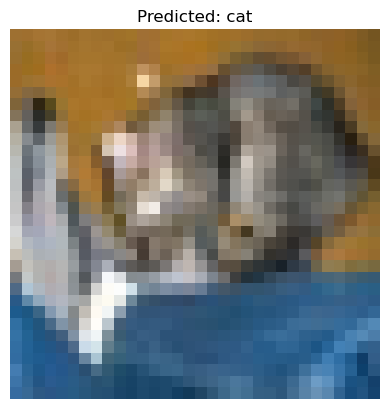

In [9]:

# 🔮 Make Predictions

predictions = cnn_model.predict(x_test)

predicted_class = np.argmax(predictions[0])

plt.imshow(x_test[0])
plt.title(f"Predicted: {class_names[predicted_class]}")
plt.axis("off")
plt.show()



# 🔥 Part 2 — Transfer Learning

Now we will use a pretrained CNN.

We will use:
## MobileNetV2

Why?
✅ Lightweight  
✅ Fast  
✅ Excellent pretrained features  
✅ Industry standard  

---

# 🧠 Transfer Learning Workflow

```text
Load Pretrained Model
 ↓
Freeze Base Layers
 ↓
Add Custom Classifier
 ↓
Train New Head
 ↓
Fine-Tune Selected Layers
```


Training Shape: (50000, 32, 32, 3)
Testing Shape: (10000, 32, 32, 3)


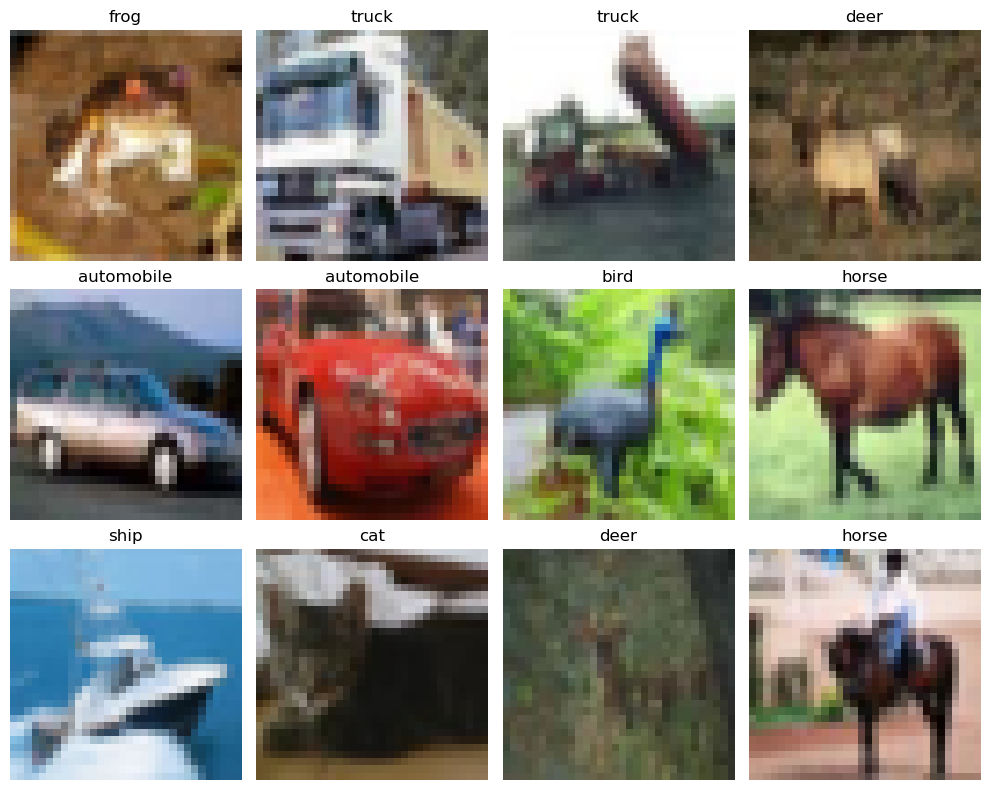

Transfer Learning Dataset Shape: (50000, 96, 96, 3)
Base Model Loaded Successfully


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)            │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_96 (Functional)     │ (None, 3, 3, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ ?                           │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/10
 335/1563 ━━━━━━━━━━━━━━━━━━━━ 1:21 66ms/step - accuracy: 0.5023 - loss: 1.4701

In [ ]:
# =========================================
# TRANSFER LEARNING WITH MOBILENETV2
# FULL WORKING CODE
# =========================================

# =========================================
# IMPORT LIBRARIES
# =========================================

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

import matplotlib.pyplot as plt
import numpy as np


# =========================================
# LOAD CIFAR-10 DATASET
# =========================================

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

print("Training Shape:", x_train.shape)
print("Testing Shape:", x_test.shape)


# =========================================
# VISUALIZE SAMPLE IMAGES
# =========================================

plt.figure(figsize=(10,8))

for i in range(12):
    
    plt.subplot(3,4,i+1)
    
    plt.imshow(x_train[i])
    
    plt.title(class_names[y_train[i][0]])
    
    plt.axis("off")

plt.tight_layout()
plt.show()


# =========================================
# RESIZE IMAGES FOR MOBILENETV2
# =========================================

# MobileNetV2 needs larger images

x_train_tf = tf.image.resize(x_train, (96,96))
x_test_tf = tf.image.resize(x_test, (96,96))


# =========================================
# CONVERT TO FLOAT32
# =========================================

x_train_tf = tf.cast(x_train_tf, tf.float32)
x_test_tf = tf.cast(x_test_tf, tf.float32)


# =========================================
# APPLY MOBILENET PREPROCESSING
# =========================================

# IMPORTANT:
# preprocess_input() handles scaling internally

x_train_tf = preprocess_input(x_train_tf)
x_test_tf = preprocess_input(x_test_tf)

print("Transfer Learning Dataset Shape:", x_train_tf.shape)


# =========================================
# DATA AUGMENTATION
# =========================================

data_augmentation = tf.keras.Sequential([
    
    layers.RandomFlip("horizontal"),
    
    layers.RandomRotation(0.1),
    
    layers.RandomZoom(0.1)
])


# =========================================
# LOAD PRETRAINED MOBILENETV2
# =========================================

base_model = MobileNetV2(
    
    input_shape=(96,96,3),
    
    include_top=False,
    
    weights='imagenet'
)

# Freeze pretrained layers

base_model.trainable = False

print("Base Model Loaded Successfully")


# =========================================
# BUILD TRANSFER LEARNING MODEL
# =========================================

transfer_model = models.Sequential([
    
    data_augmentation,
    
    base_model,
    
    layers.GlobalAveragePooling2D(),
    
    layers.Dense(128, activation='relu'),
    
    layers.Dropout(0.3),
    
    layers.Dense(10, activation='softmax')
])

transfer_model.summary()


# =========================================
# COMPILE MODEL
# =========================================

transfer_model.compile(
    
    optimizer='adam',
    
    loss='sparse_categorical_crossentropy',
    
    metrics=['accuracy']
)


# =========================================
# TRAIN TRANSFER LEARNING MODEL
# =========================================

transfer_history = transfer_model.fit(
    
    x_train_tf,
    
    y_train,
    
    epochs=10,
    
    validation_data=(x_test_tf, y_test)
)


# =========================================
# EVALUATE MODEL
# =========================================

test_loss, test_acc = transfer_model.evaluate(
    
    x_test_tf,
    
    y_test
)

print("Transfer Learning Accuracy:", test_acc)


# =========================================
# PLOT ACCURACY
# =========================================

plt.figure(figsize=(8,5))

plt.plot(
    transfer_history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    transfer_history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Transfer Learning Accuracy")

plt.legend()

plt.show()


# =========================================
# MAKE PREDICTIONS
# =========================================

predictions = transfer_model.predict(x_test_tf)

predicted_class = np.argmax(predictions[0])

actual_class = y_test[0][0]

plt.figure(figsize=(4,4))

plt.imshow(x_test[0])

plt.title(
    f"Predicted: {class_names[predicted_class]}"
    f" | Actual: {class_names[actual_class]}"
)

plt.axis("off")

plt.show()


# =========================================
# FINE-TUNING
# =========================================

print("Starting Fine-Tuning...")


# Unfreeze model

base_model.trainable = True


# Freeze earlier layers
# Train only deeper layers

for layer in base_model.layers[:-30]:
    
    layer.trainable = False


# Recompile with VERY SMALL learning rate

transfer_model.compile(
    
    optimizer=tf.keras.optimizers.Adam(1e-5),
    
    loss='sparse_categorical_crossentropy',
    
    metrics=['accuracy']
)


# =========================================
# FINE-TUNE MODEL
# =========================================

fine_tune_history = transfer_model.fit(
    
    x_train_tf,
    
    y_train,
    
    epochs=5,
    
    validation_data=(x_test_tf, y_test)
)


# =========================================
# FINAL EVALUATION
# =========================================

final_loss, final_acc = transfer_model.evaluate(
    
    x_test_tf,
    
    y_test
)

print("Final Fine-Tuned Accuracy:", final_acc)


# 🔧 Fine-Tuning CNN

Now we unfreeze some deeper layers.

Why?
Because pretrained features may not perfectly match CIFAR-10 images.

Fine-tuning helps adapt the model.


In [ ]:

# Unfreeze Last Layers

base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

# Use Smaller Learning Rate

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Fine-Tune Model

fine_tune_history = transfer_model.fit(
    x_train_tf,
    y_train,
    epochs=2,
    validation_data=(x_test_tf, y_test)
)



# 📊 CNN vs Transfer Learning

| Feature | CNN From Scratch | Transfer Learning |
|---|---|---|
| Training Time | High | Low |
| Data Requirement | Large | Smaller |
| Accuracy | Moderate | Often Higher |
| Compute Cost | High | Lower |
| Real-World Usage | Less Common | Very Common |

---

# 💼 Real-World Applications

✅ Medical Imaging  
✅ Face Recognition  
✅ Self-Driving Cars  
✅ Industrial Defect Detection  
✅ Retail Product Recognition  
✅ Agriculture Disease Detection  



# 🧪 Practice Exercises

## Beginner
- Change number of CNN layers
- Try different optimizers
- Increase epochs

## Intermediate
- Add Batch Normalization
- Add Data Augmentation
- Try Dropout

## Advanced
- Use ResNet50
- Use EfficientNet
- Build Cat vs Dog classifier

---

# 🎯 Key Takeaways

✅ CNNs are specialized for images  
✅ Convolution extracts patterns  
✅ Pooling reduces dimensions  
✅ Transfer Learning saves time & data  
✅ Fine-Tuning improves performance  
✅ Pretrained models dominate industry AI systems  
